In [22]:
from sklearnex import patch_sklearn
patch_sklearn()
import pandas as pd
import seaborn as sns
from scipy.stats import zscore
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sys,os
sys.path.append( '../../results_analysis/')
import utils
from utils import generate_anndata_from_ark_analysis
output_fig = '../../figures/diff_expr_marker/'
import feather
import scanpy as sc
from sklearn.linear_model import LogisticRegression
#from cuml.linear_model import LogisticRegression cuml does not work for multiclass regression
from sklearn.model_selection import train_test_split
import random
#import cuml
from sklearn.metrics import balanced_accuracy_score, accuracy_score

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


It contains 2 parts:
- Analysis of batch effects
- Clustering of pixie2 clusters (not completed)

## Part 1
### check for batch effects using linear regression 

In [42]:
cell_table = pd.read_csv('../../../segmentation/cell_table_Denoised/cell_table_size_normalized_cell_labels.csv')

In [43]:
intensities_protein = cell_table.iloc[:,1:cell_table.columns.get_loc('label')]

In [44]:
adata = sc.AnnData(intensities_protein, obsm={"spatial": cell_table[['centroid-0', 'centroid-1']].values})

/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [31]:
adata = sc.read_h5ad('../../results_analysis/data/sc_protein.h5ad')
#Normalise each channel independently by quantile
if np.any(adata.X>1):
    adata.X = utils.normalise(adata,quantile=0.95)


In [32]:
X = adata.X #adata.obsm['X_pca']
y = adata.obs.acquisition_ID

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.33,stratify=y)

In [34]:
clf_partition = LogisticRegression().fit(X = X_train, y = y_train)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/daal4py/sklearn/linear_model/logistic_path.py:623: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
!ls ../../../

IMC_Denoise		 Img_Denoised	 image_data    spatial_analysis
IMC_SegmentationResults  Untitled.ipynb  panel.csv     split_channels
IMC_analysis		 combined_tiff	 pixie	       split_channels_nohpf
IMC_data		 file_structure  segmentation


In [9]:
#save the model
from joblib import dump, load

In [10]:
dump(clf_partition, 'batch_effect_model_Denoised.joblib') 

['batch_effect_model_Denoised.joblib']

In [3]:
 adata.write('data/pixel_cluster_in_cell.h5ad')

In [20]:
adata.obs['leiden

,acquisition,Leap_ID,n_genes,leiden
1,Leap001_10,Leap001,3,5
2,Leap001_10,Leap001,3,5
4,Leap001_10,Leap001,4,5
5,Leap001_10,Leap001,2,102
6,Leap001_10,Leap001,2,159
...,...,...,...,...
3852744,Leap096_9,Leap096,4,34
3852745,Leap096_9,Leap096,5,3
3852746,Leap096_9,Leap096,3,29
3852747,Leap096_9,Leap096,4,6



- ```batch_effect_model.joblib``` was generated without IMC Denoised
- ```batch_effect_model_Denoised.joblib``` was generated with IMC Denoised and no qc



In [21]:
X_train

array([[12.12409668, 11.10279948, 18.56560262, ...,  9.68857218,
        11.80157674,  1.6887675 ],
       [ 1.62087307,  0.78678985,  0.84817181, ...,  0.95842724,
         0.10907822,  0.3401499 ],
       [ 4.15404389,  2.10830625,  2.95761466, ...,  2.36833854,
         3.48837785,  0.36554602],
       ...,
       [ 0.46223216,  1.84383495,  5.99180079, ...,  3.01810899,
         0.09949432,  0.55663863],
       [ 0.24499749,  0.77565859,  1.87893577, ...,  2.18048746,
         0.74667921,  0.19096692],
       [ 0.40821355,  3.93967905,  8.1705785 , ...,  7.3813452 ,
         1.19582096,  1.07161159]])

In [14]:
#to load the model saved on the disk
clf_partition = load('batch_effect_model_Denoised.joblib')#load('batch_effect_model.joblib') #

Text(95.72222222222221, 0.5, 'mapped acquisition_ID')

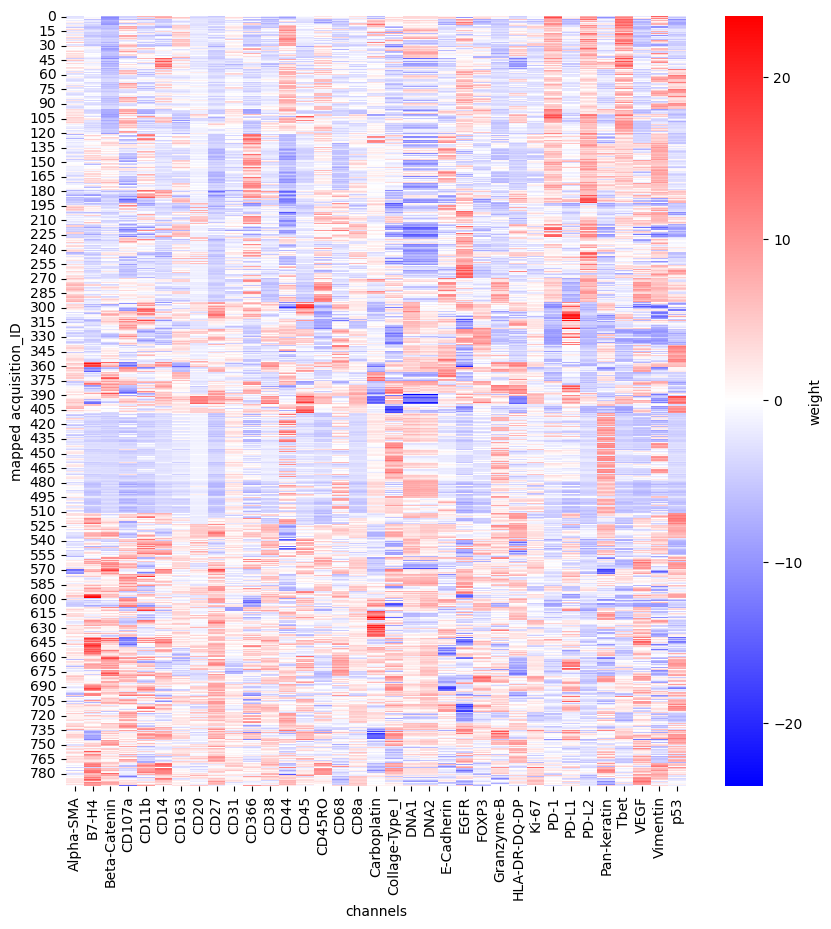

In [38]:
plt.figure(figsize=(10,10))
ax = sns.heatmap(pd.DataFrame(clf_partition.coef_,columns = adata.var.index),cmap='bwr',cbar_kws={'label':'weight'})
plt.xlabel('channels')
plt.ylabel('mapped acquisition_ID')
#plt.savefig('batch_effects.png')
#plt.xticks(rotation=30)

In [40]:

print(balanced_accuracy_score(y_train, clf_partition.predict(X_train)))
y_pred = clf_partition.predict(X_test)
print(balanced_accuracy_score(y_test, y_pred)

0.3684276215684904
0.3629307123448704


In [37]:
balanced_accuracy_score(y_test, clf_partition.predict(X_test))

0.3629307123448704

In [39]:
def random_accuracy(y, y_pred,n_shuffling=5):
    '''Function computes the accuracy score for random permutation'''
    y_shuffle = np.copy(y_pred)
    data  = np.zeros((n_shuffling,2))
    for i in range(n_shuffling):
        np.random.shuffle(y_shuffle)
        data[i] =accuracy_score(y, y_shuffle),balanced_accuracy_score(y, y_shuffle)
    return data

ran_accuracy = random_accuracy(y_test, y_pred,5)

In [19]:
ran_accuracy

array([[0.00173941, 0.00125861],
       [0.0017371 , 0.00127013],
       [0.00174941, 0.00128167],
       [0.00170095, 0.00123322],
       [0.00172941, 0.00127949]])

In [23]:

clf = LogisticRegression().fit(X = X, y = y)

AnnData object with n_obs × n_vars = 3852749 × 30
    obs: 'acquisition', 'Leap_ID'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap', 'Leap_ID_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
y_pred = clf.predict(X)

In [115]:
adata.var.highly_variable[adata.var.highly_variable]

CD27    True
CD38    True
Name: highly_variable, dtype: bool

In [4]:
sc.tl.pca(adata, svd_solver='arpack',use_highly_variable=False)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_utils.py:441: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/giuseppe/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:399: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/giuseppe/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:399: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


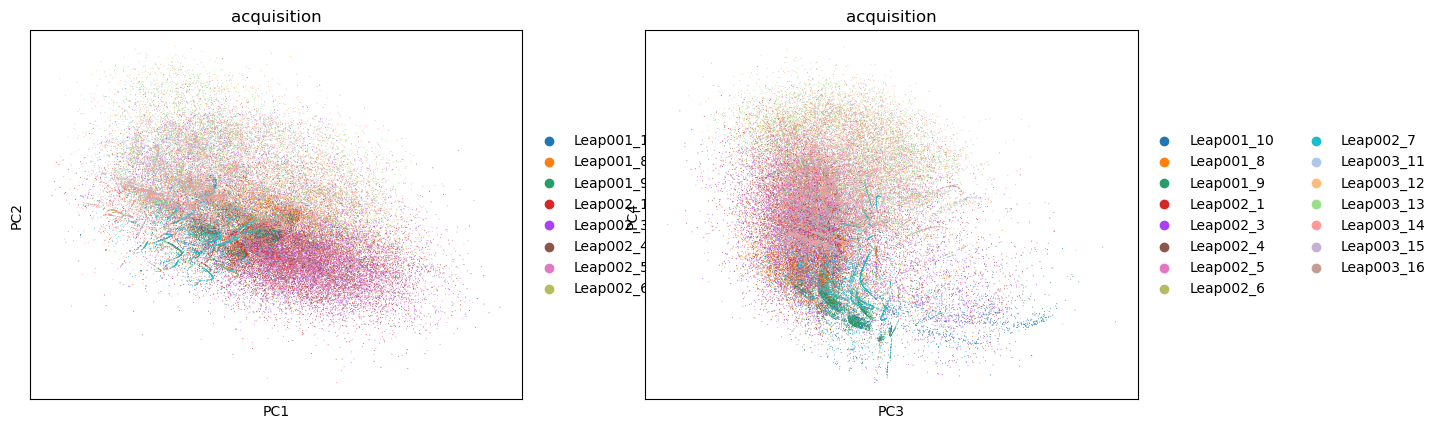

In [10]:
sc.pl.pca(adata[adata.obs.Leap_ID.isin(['Leap001','Leap002','Leap003'])],  color='acquisition',components = ['1,2','3,4'], ncols=2)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_utils.py:441: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/giuseppe/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:399: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/giuseppe/anaconda3/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:399: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


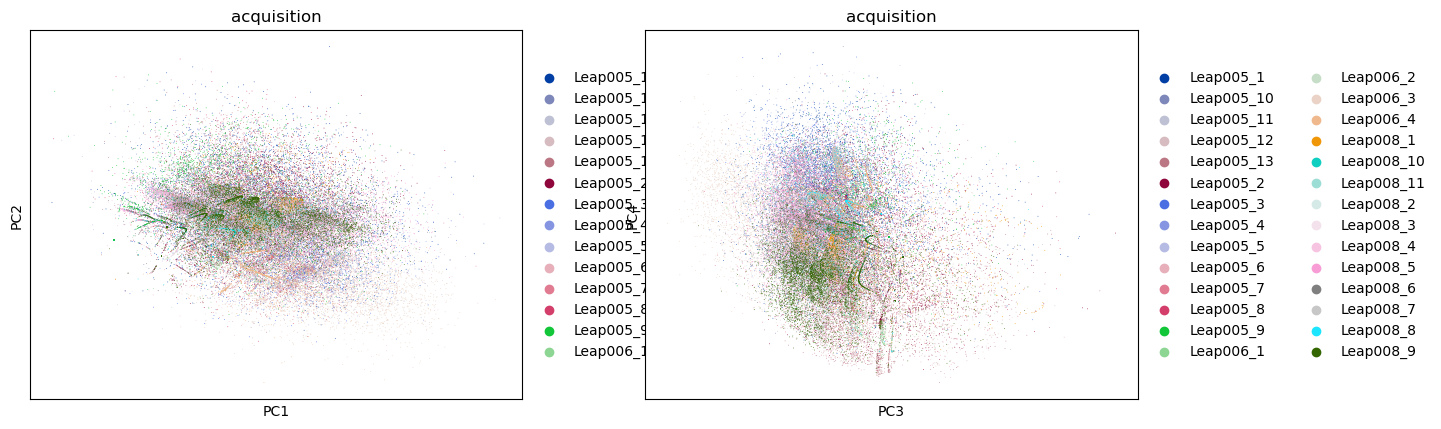

In [16]:
sc.pl.pca(adata[adata.obs.Leap_ID.isin(['Leap005','Leap006','Leap008'])],  color='acquisition',components = ['1,2','3,4'], ncols=2)

In [2]:
read_adata = True
if read_adata:
    adata = sc.read_h5ad('data/pixel_cluster_in_cell.h5ad')
else:
    base_dir = "../../"
    cell_cluster_prefix = "all"
    cell_output_dir = '%s_cell_output_dir' % cell_cluster_prefix
    cluster_counts_name = os.path.join("pixie", cell_output_dir, 'cluster_counts.feather')
    
    cluster_counts = feather.read_dataframe(os.path.join(base_dir, cluster_counts_name))
    cluster_counts.index = cluster_counts.index.map(str)
    cluster_counts['fov'] = cluster_counts['fov'].astype('category')
    frac_counts = cluster_counts.loc[:,cluster_counts.columns.str.contains('pixel_meta_cluster_rename')]#take the n of pixel in a cell
    frac_counts = frac_counts.div(cluster_counts.cell_size,axis =0)#divide by the size of the cell, every cell add up to 1 now
    adata = sc.AnnData(frac_counts)
    adata.var.index = adata.var.index.str.lstrip('pixel_meta_cluster_rename_')
    adata.obs['acquisition'] = pd.DataFrame(cluster_counts.fov)
    adata.obs.acquisition.astype('category')
    adata.obs['Leap_ID'] = adata.obs.acquisition.str.split('_',n = 1).str[0].astype('category')
    sc.pp.filter_cells(adata, min_genes=2)
    if np.any(adata.X.sum(axis = 1)!=1):
        #should already been normalised before if not
        sc.pp.normalize_total(adata, target_sum=1)
    #sc.pp.log1p(adata) not needed because data [0,1] already, so it is basically identity
    sc.pp.highly_variable_genes(adata)
    adata.var.highly_variable[adata.var.highly_variable]
    adata.raw = adata
    #adata.scale(adata, max_value=5) it subtracts, for all cells, the mean protein level. This is biological info we don't want to disregard. Plus, the data are already in[0,1], this function messes them up. 
    sc.tl.pca(adata, svd_solver='arpack',use_highly_variable=False)
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=10,method = 'rapids')
    sc.tl.leiden(adata)

Let us inspect the contribution of single PCs to the total variance in the data. This gives us information about how many PCs we should consider in order to compute the neighborhood relations of cells, e.g. used in the clustering function sc.tl.louvain() or tSNE sc.tl.tsne()

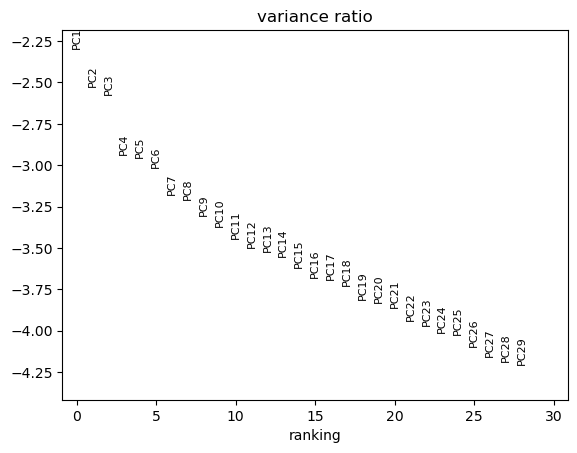

In [120]:

sc.pl.pca_variance_ratio(adata, log=True)


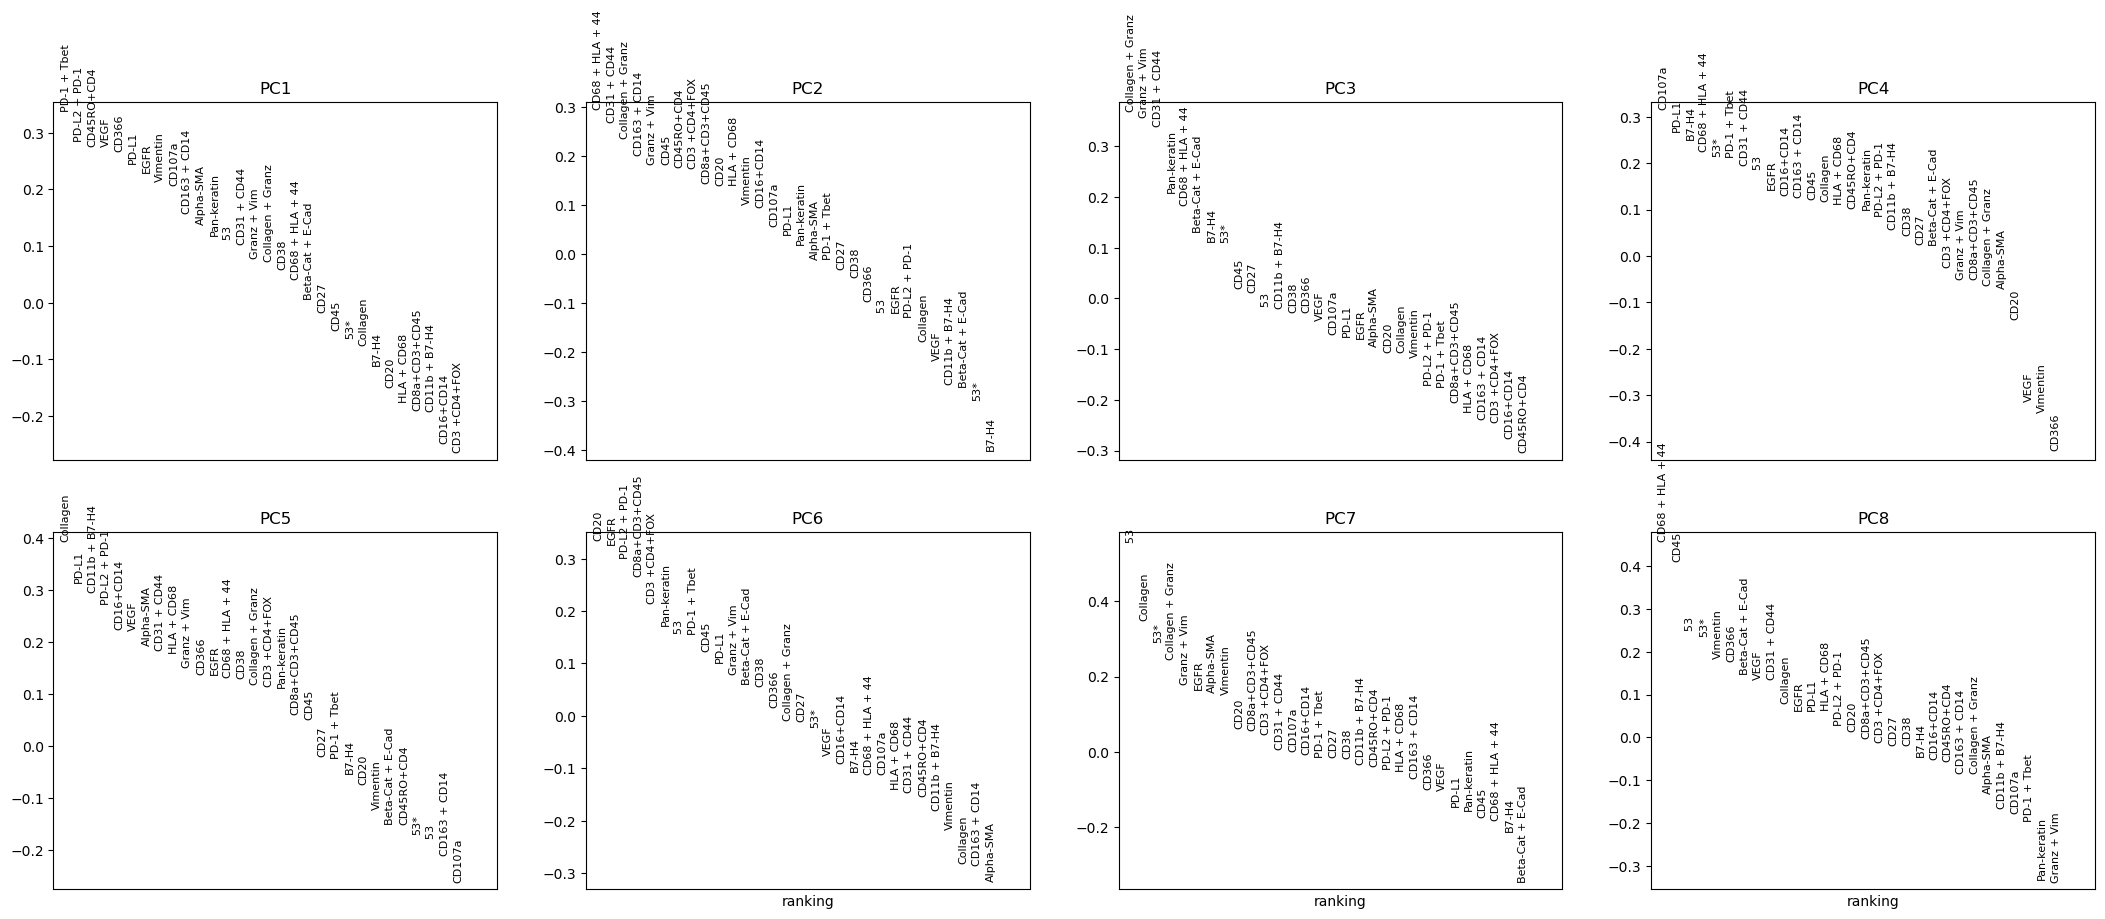

In [8]:
#Plot loadings
sc.pl.pca_loadings(adata, components=[1,2,3,4,5,6,7,8])

In [ ]:
sc.tl.leiden(adata)

In [20]:
pd.DataFrame(adata.obsm['X_pca'],adata.obs.acquisition)
adata.obs.acquisition.cat.codes

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
acquisition,,,,,,,,,,,,,,,,,,,,,
Leap001_10,0.774498,0.686388,0.123482,-2.055907,-1.661941,-0.543909,0.590299,0.677637,-0.381242,-0.144368,...,-0.409963,0.789711,-1.355891,-0.634253,0.112903,0.624518,-0.173734,-1.635447,-0.078045,-0.442628
Leap001_10,2.017573,-0.014440,-0.027567,-3.770846,-0.843971,-0.641379,0.106001,1.407076,-0.368360,0.349516,...,0.402362,0.535477,-0.640929,-0.292968,-0.126307,0.573132,0.040646,-0.814425,0.102220,-0.352766
Leap001_10,2.106940,0.732422,-0.832328,-2.328415,-1.617925,-1.104476,0.225660,0.752067,-0.351223,0.444927,...,-1.222730,-0.472032,-1.034796,-1.370765,0.051548,1.108569,0.499298,-0.096029,-0.630247,0.692488
Leap001_10,0.774498,0.686388,0.123482,-2.055907,-1.661941,-0.543909,0.590299,0.677637,-0.381242,-0.144368,...,-0.409963,0.789711,-1.355891,-0.634253,0.112903,0.624518,-0.173734,-1.635447,-0.078045,-0.442628
Leap001_10,2.427575,1.211879,-1.359455,-2.055091,-2.143800,-1.853836,0.052914,0.555311,-0.799490,0.787975,...,-0.977649,-0.626346,-0.872904,-0.885901,0.260086,0.594871,0.206893,-0.504313,0.017291,-0.334311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Leap096_9,0.779262,-1.492522,0.205051,-2.376924,1.257817,-0.594925,-0.081078,0.564988,0.321464,-0.431344,...,0.530105,0.237889,0.736138,0.966046,0.159976,-1.548021,0.220633,0.361722,-0.161339,0.363572
Leap096_9,1.031696,-1.462351,-0.050263,-2.242854,1.690493,-1.552248,0.410955,0.004876,1.702334,-0.577590,...,0.345551,-0.314219,0.674260,0.837281,-0.206387,-0.677414,0.075965,0.263154,-0.237293,0.184123
Leap096_9,1.216817,-1.051045,0.176896,-2.490370,0.880404,-0.380043,0.183815,1.010887,0.090495,0.248623,...,0.895159,0.913611,0.598871,0.066746,0.858581,-1.342625,0.354869,0.402643,0.662920,0.583392


<Axes: ylabel='Count'>

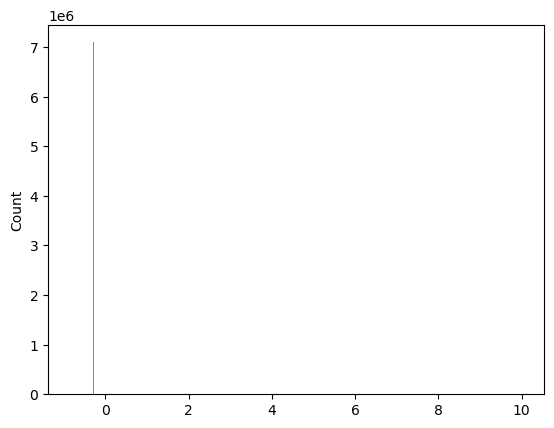

In [125]:
sns.histplot(X.reshape(-1))

In [107]:
X = adata.X #adata.obsm['X_pca']
y = adata.obs.acquisition

In [109]:
clf = LogisticRegression(random_state=0,solver = 'lbfgs').fit(X = X, y = y)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [110]:
y_pred = clf.predict(X)

predict acccuracy of slide_ID classification

In [111]:

print(accuracy_score(y, y_pred),balanced_accuracy_score(y, y_pred))

0.12915219756075466 0.10501507675463709


In [ ]:
def random_accuracy(y, y_pred,n_shuffling=5):
    '''Function computes the accuracy score for random permutation'''
    y_shuffle = np.copy(y_pred)
    data  = np.zeros((n_shuffling,2))
    for i in range(n_shuffling):
        np.random.shuffle(y_shuffle)
        data[i] =accuracy_score(y, y_shuffle),balanced_accuracy_score(y, y_shuffle)
    return data

In [88]:

ran_accuracy = random_accuracy(y, y_pred,100)

<Axes: ylabel='Count'>

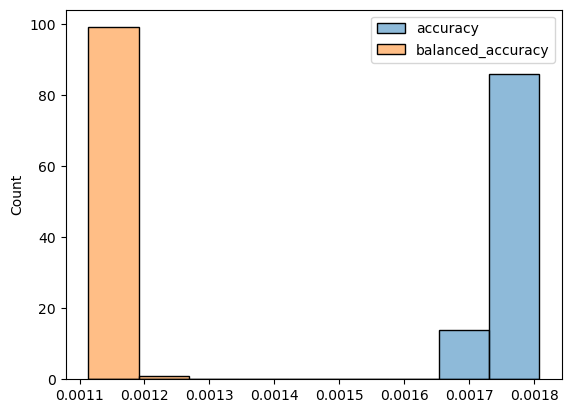

In [102]:
import seaborn as sns
sns.histplot(pd.DataFrame(ran_accuracy,columns=['accuracy','balanced_accuracy']))

<Axes: ylabel='Count'>

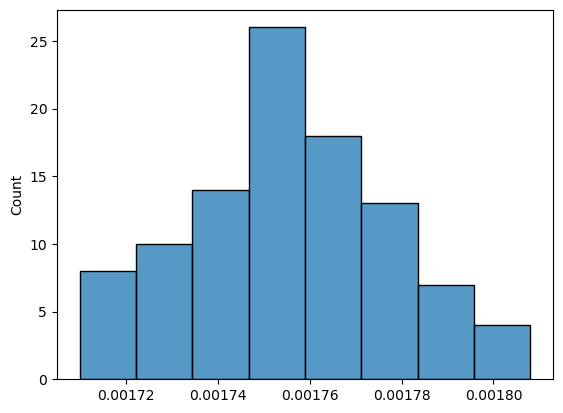

In [101]:
sns.histplot(ran_accuracy[:,0])

Text(50.722222222222214, 0.5, 'mapped acquisition_ID')

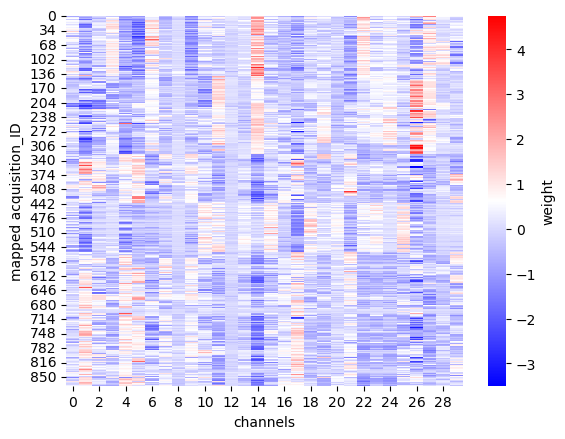

In [120]:
#y.str.split('_',n = 1).str[0]
def acq_to_Leap_ID(acq_ID):
    return pd.Series(acq_ID).str.split('_',n = 1).str[0]
print(accuracy_score(acq_to_Leap_ID(y), acq_to_Leap_ID(y_pred)),balanced_accuracy_score(acq_to_Leap_ID(y), acq_to_Leap_ID(y_pred)))


0.2972757893130334 0.2956564128016334


In [121]:
random_accuracy(acq_to_Leap_ID(y), acq_to_Leap_ID(y_pred),1)

array([[0.01436585, 0.01126895],
       [0.01428253, 0.01117554],
       [0.01433885, 0.01124618],
       [0.01431523, 0.01119629],
       [0.01419117, 0.01110931],
       [0.01428409, 0.01120576],
       [0.01439855, 0.01127944],
       [0.01435754, 0.01126009],
       [0.01436611, 0.011234  ],
       [0.01425787, 0.0111909 ]])

In [10]:
#%time sc.pp.neighbors(adata, n_neighbors=10,n_pcs=10)
%time sc.tl.umap(adata)

KeyboardInterrupt: 

In [112]:

sc.pl.umap(adata)


KeyError: "Could not find 'umap' or 'X_umap' in .obsm"

In [111]:
#sc.pl.umap(adata)
adata

AnnData object with n_obs × n_vars = 3852749 × 30
    var: 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [83]:
cluster_counts#.loc[:,cluster_counts.columns.str.contains('pixel_meta_cluster_rename')

,cell_size,fov,label,pixel_meta_cluster_rename_Alpha-SMA,pixel_meta_cluster_rename_B7-H4,pixel_meta_cluster_rename_Beta-Cat + E-Cad,pixel_meta_cluster_rename_CD107a,pixel_meta_cluster_rename_CD11b + B7-H4,pixel_meta_cluster_rename_CD16+CD14,pixel_meta_cluster_rename_CD163 + CD14,...,pixel_meta_cluster_rename_Granz + Vim,pixel_meta_cluster_rename_HLA + CD68,pixel_meta_cluster_rename_PD-1 + Tbet,pixel_meta_cluster_rename_PD-L1,pixel_meta_cluster_rename_PD-L2 + PD-1,pixel_meta_cluster_rename_Pan-keratin,pixel_meta_cluster_rename_VEGF,pixel_meta_cluster_rename_Vimentin,pixel_meta_cluster_rename_p53,pixel_meta_cluster_rename_p53*
0,27.0,Leap001_10,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.0,0.0,0.0
1,28.0,Leap001_10,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,24.0,0.0,0.0
2,36.0,Leap001_10,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,5.0,22.0,0.0,0.0
3,25.0,Leap001_10,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,0.0
4,34.0,Leap001_10,5,0.0,0.0,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,5.0,24.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3852744,77.0,Leap096_9,3183,0.0,0.0,0.0,0.0,27.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0
3852745,35.0,Leap096_9,3184,8.0,0.0,0.0,0.0,9.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,16.0,0.0,0.0,0.0
3852746,27.0,Leap096_9,3185,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0
3852747,25.0,Leap096_9,3186,0.0,0.0,0.0,0.0,7.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0


## Here I check marker expression in cell types

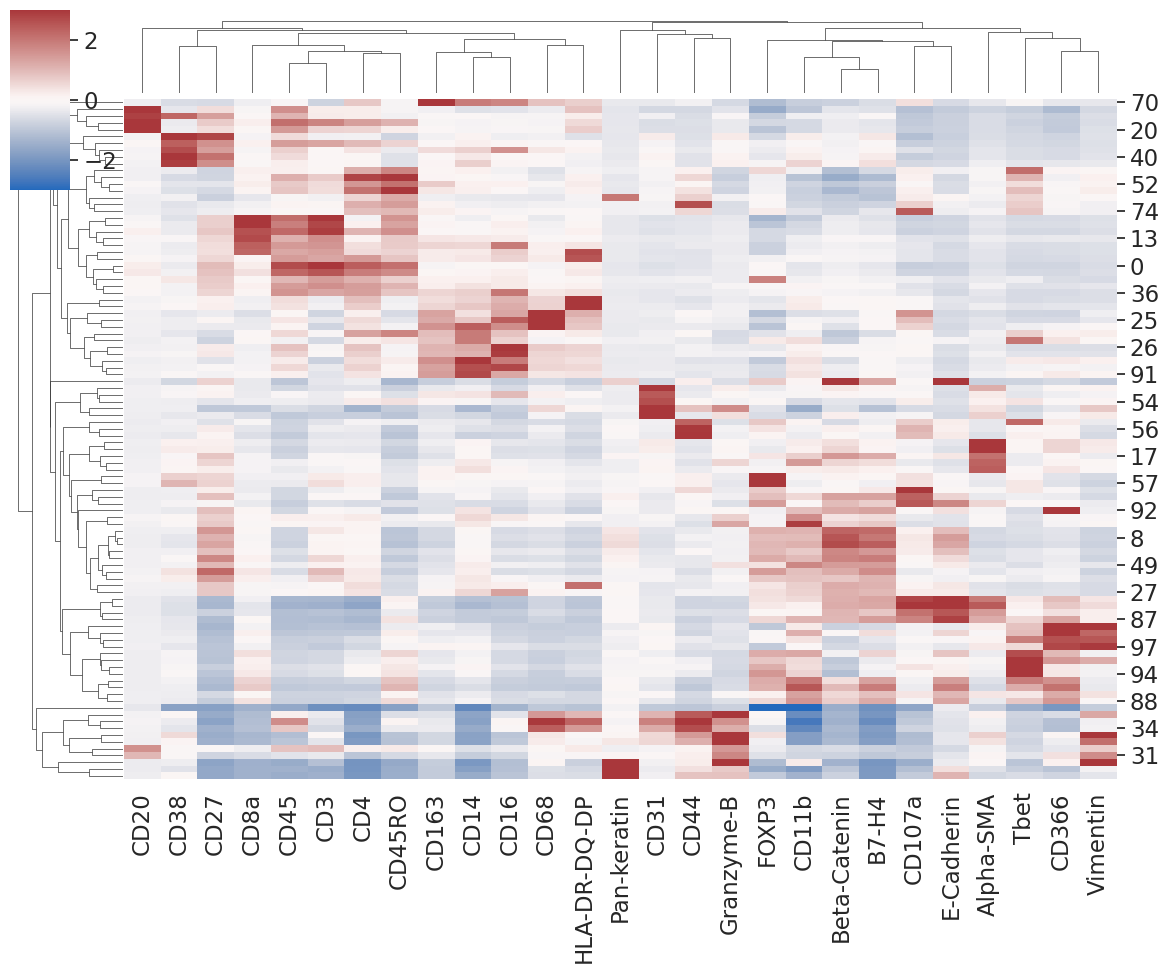

In [22]:
cell_som_cluster = pd.read_csv('../../../pixie/all_cell_output_dir/cell_som_cluster_channel_avg.csv')
num_clusters = cell_som_cluster.iloc[:,1:cell_som_cluster.columns.get_loc('cell_meta_cluster')]
sns.clustermap(num_clusters,cmap ='vlag',z_score=1,vmin = -3,vmax = 3,dendrogram_ratio=0.1,figsize = (12,10))
plt.show()

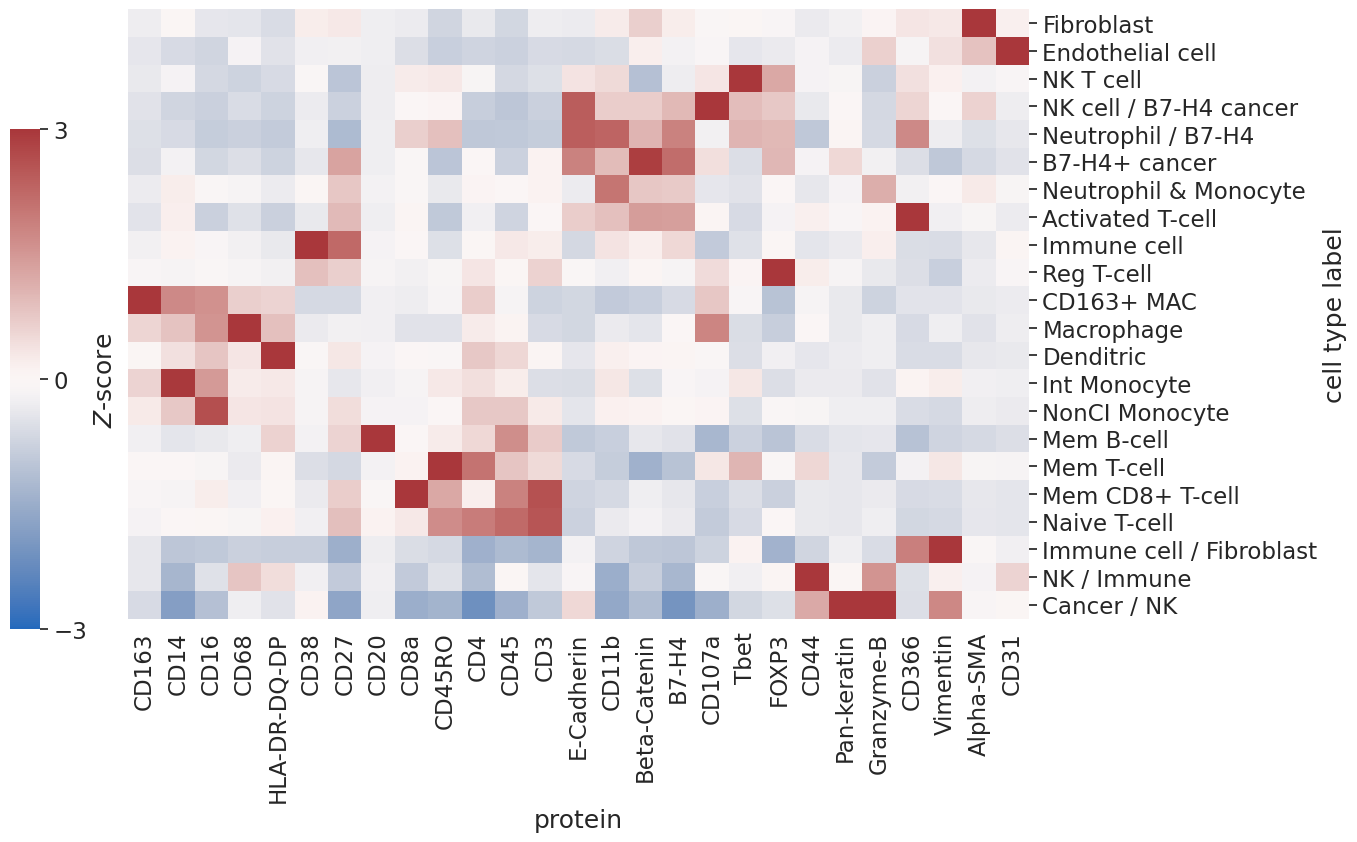

In [30]:
cell_meta = pd.read_csv('../../../pixie/all_cell_output_dir/cell_meta_cluster_channel_avg.csv')
num_meta =  cell_meta.iloc[:,1:cell_meta.columns.get_loc('cell_meta_cluster_rename')+1]#.sort_values(by = 'cell_meta_cluster_rename')
num_meta = num_meta.set_index('cell_meta_cluster_rename')
cg = sns.clustermap(num_meta,cmap ='vlag',z_score=1,vmin = -3.,vmax = 3.,cbar_pos=(0.09,0.2,.02,0.5),cbar_kws={"ticks":[-3,0,3]},figsize = (15,10))
cg.ax_heatmap.set(xlabel = 'protein',ylabel = 'cell type label')
cg.ax_cbar.set(ylabel = '$Z$-score')
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)
sns.set(font_scale=1.5)
#plt.tight_layout()
#plt.savefig(output_fig+'meta_cluster.png')
#plt.savefig('../../figures/spatial/Denoised_ProteinExpression.png',transparent = True)

In [15]:
cell_meta = pd.read_csv('../../../pixie/all_cell_output_dir/cell_meta_cluster_channel_avg.csv')
num_meta =  cell_meta.iloc[:,1:cell_meta.columns.get_loc('cell_meta_cluster_rename')+1]#.sort_values(by = 'cell_meta_cluster_rename')
num_meta = num_meta.set_index('cell_meta_cluster_rename')
cg = sns.clustermap(num_meta.loc[['CD11b MAC + VEGF','CD68+ MAC PD','CD8+ T-cell','Memory B-cell']],cmap ='vlag',z_score=1,vmin = -3.,vmax = 3.,cbar_pos=(0.85,0.05,.02,0.25),cbar_kws={"ticks":[-3,0,3]},figsize = (15,5))
cg.ax_heatmap.set(xlabel = 'protein',ylabel = 'cell type label')
cg.ax_cbar.set(ylabel = '$Z$-score')
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)
sns.set(font_scale=1.5)
plt.tight_layout()
#plt.savefig(output_fig+'meta_cluster_red.png')


KeyError: "None of [Index(['CD11b MAC + VEGF', 'CD68+ MAC PD', 'CD8+ T-cell', 'Memory B-cell'], dtype='object', name='cell_meta_cluster_rename')] are in the [index]"

In [28]:
sns.clustermap?

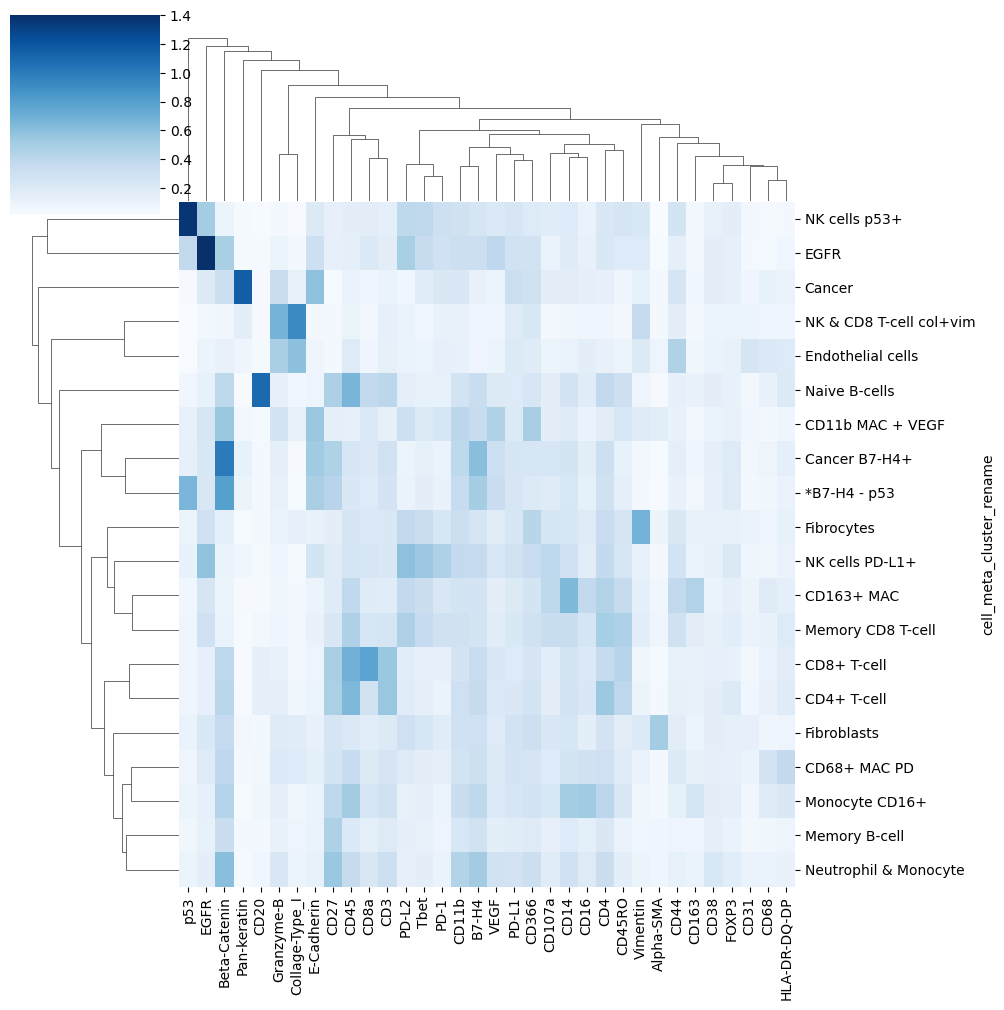

In [64]:
sns.clustermap(num_meta,cmap ='Blues',cbar_pos=(0,0.8,.15,0.2))

In [66]:
output_fig

'../figures/diff_expr_marker/'

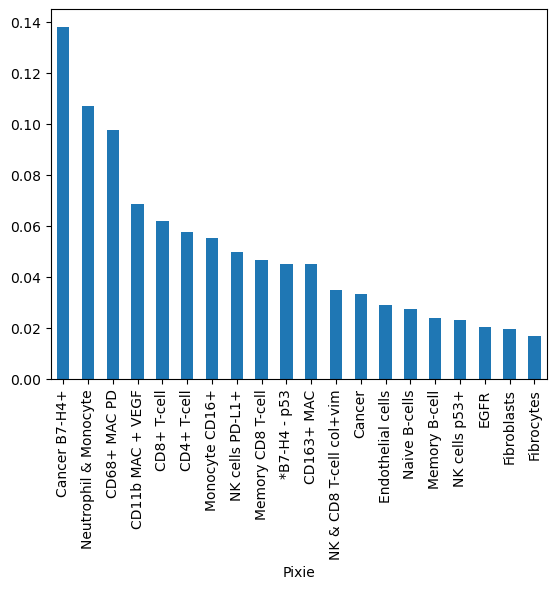

In [67]:
adata.obs.Pixie.value_counts(normalize = True).plot(kind = 'bar')
#plt.xticks(rotation = 45)
#plt.savefig(output_fig+'cell_type_proportion')

In [46]:
import scanpy as sc
adata = generate_anndata_from_ark_analysis()
adata.X = adata.X/np.quantile(adata.X,0.95,axis = 0).shape
adata.X[adata.X>1] = 1

/home/giuseppe/anaconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [47]:
# get fovs having more than 1000 cells
fovs = adata.obs.acquisition_ID.value_counts()[adata.obs.acquisition_ID.value_counts()>=1000].index
adata = adata[adata.obs.acquisition_ID.isin(fovs)]#remove fovs with less than 1000 cells

/home/giuseppe/anaconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/giuseppe/anaconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/giuseppe/anaconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/giuseppe/anaconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/giuseppe/anaconda3/envs/squidpy/lib/python3.9/site-packages/anndata/_core/anndata.py:1230: ImplicitModificationWarning: Trying to m

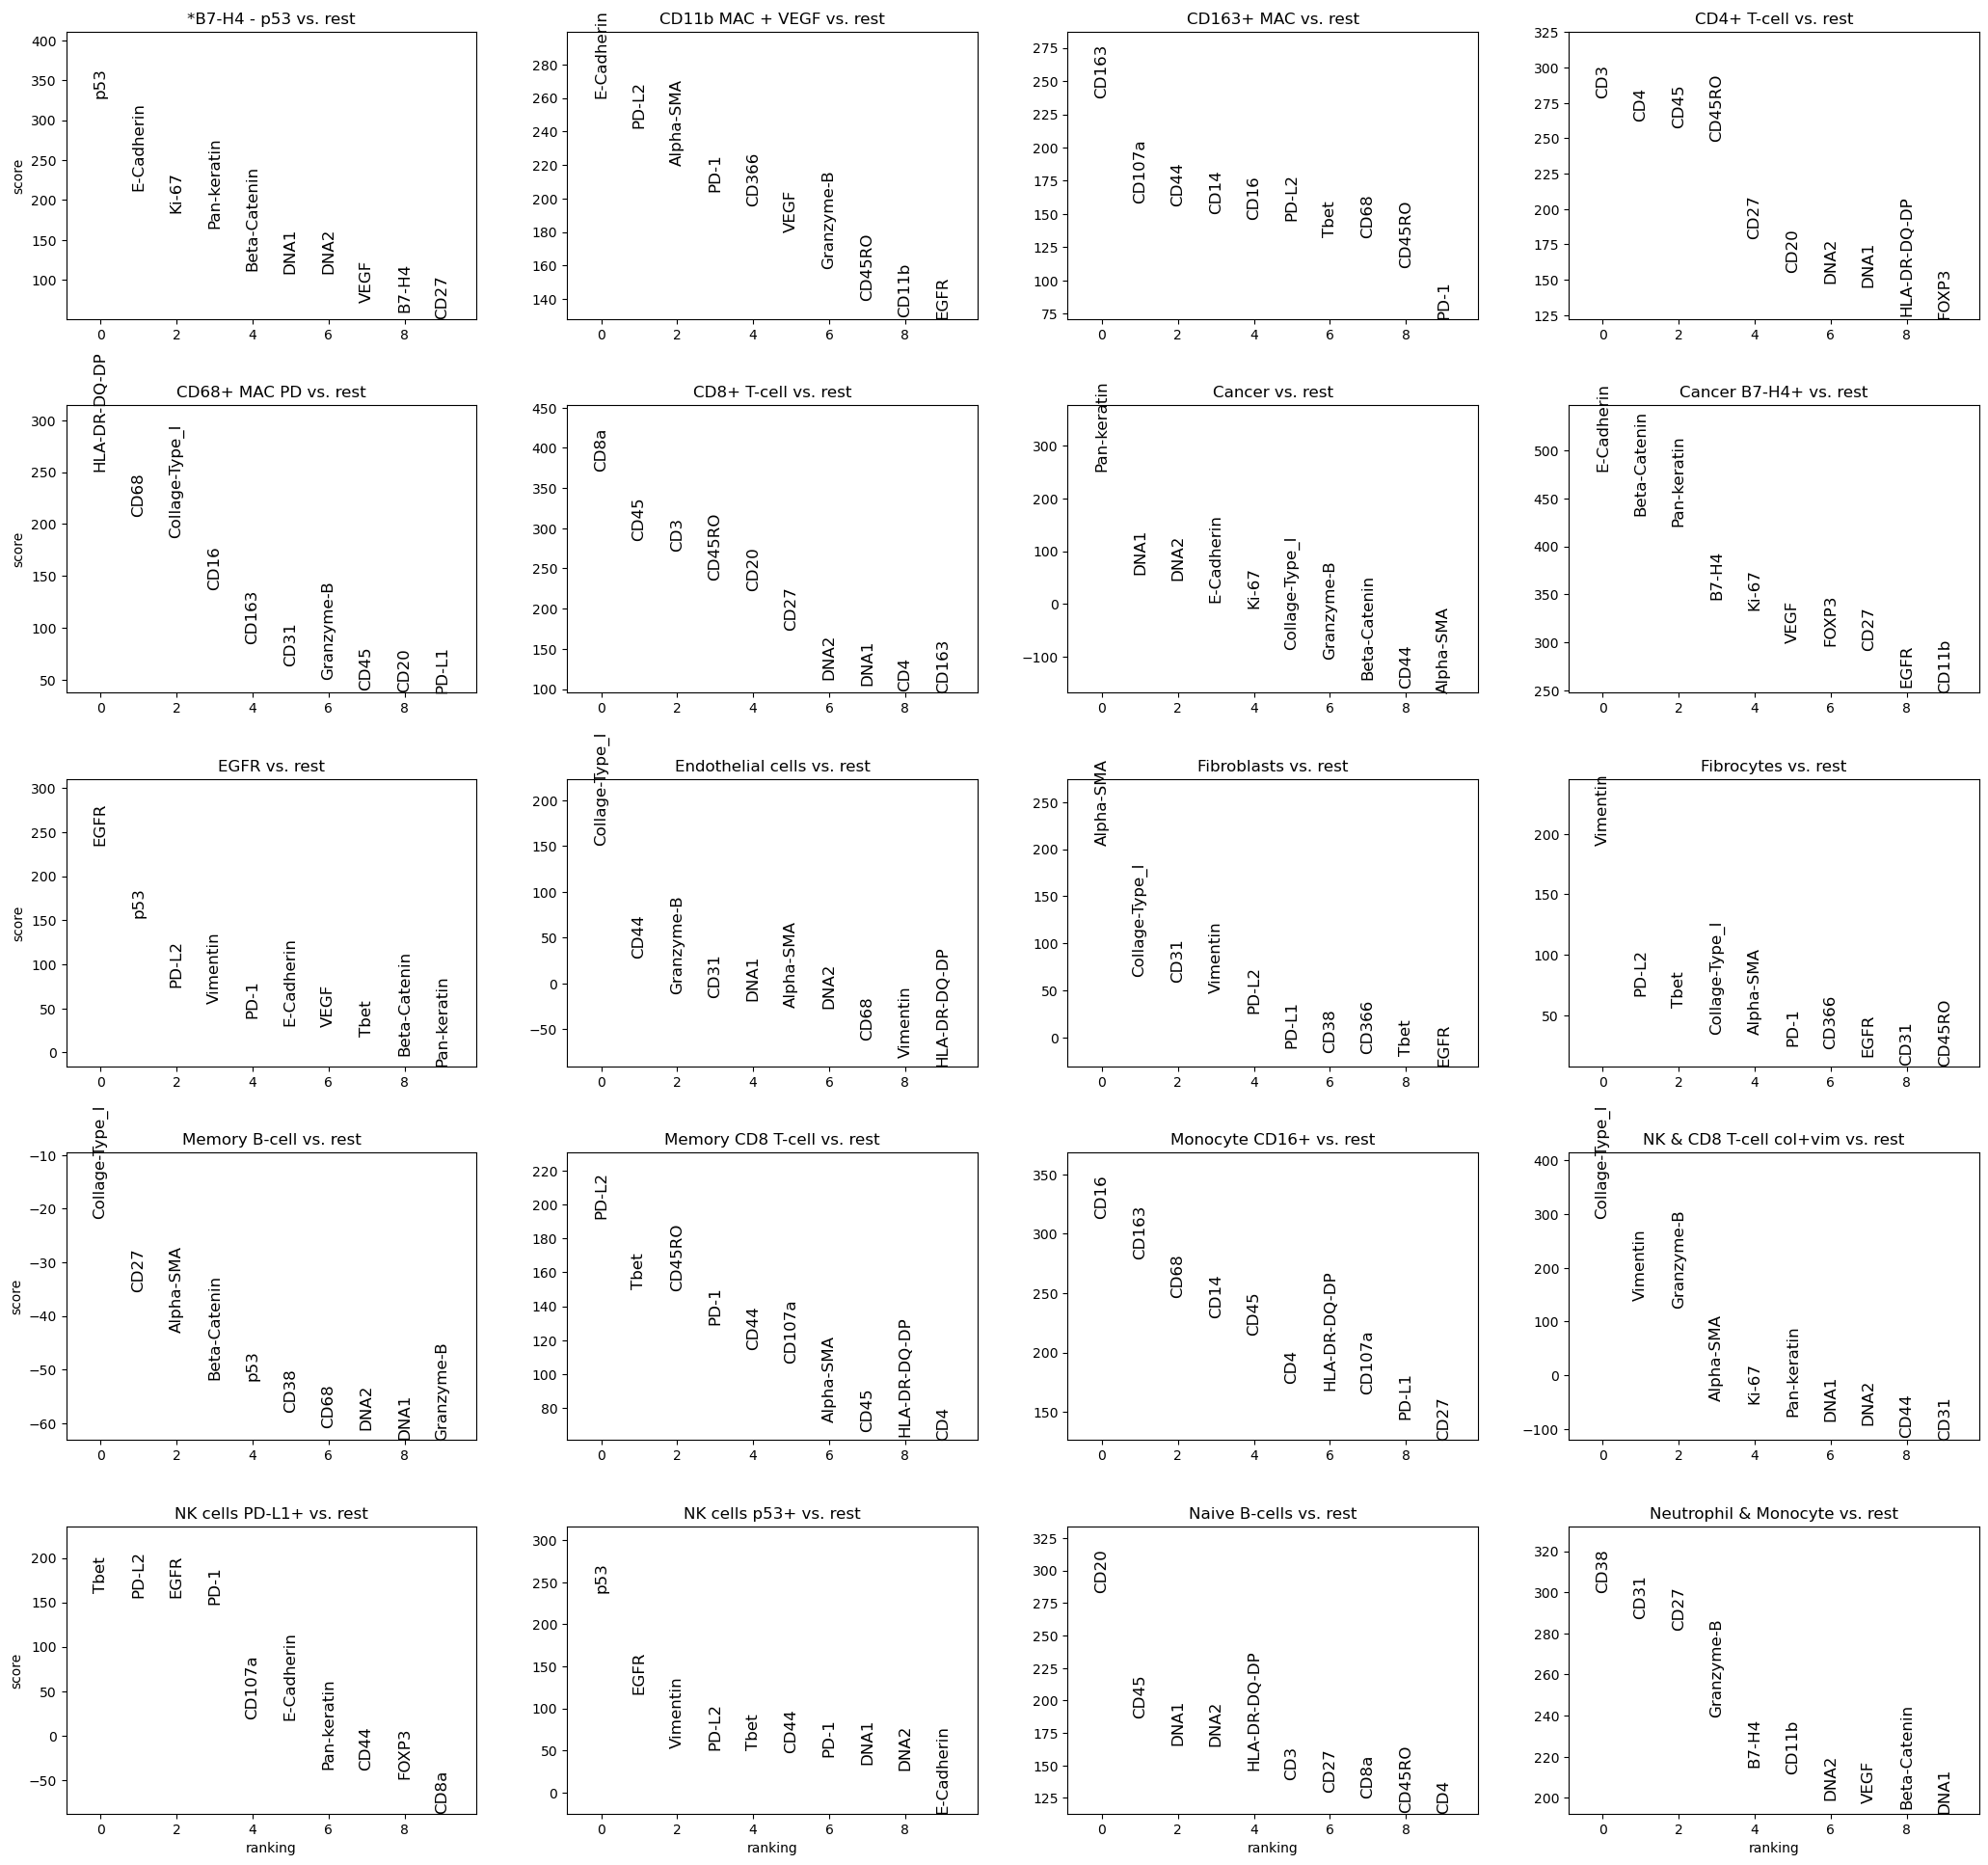

In [48]:
sc.tl.rank_genes_groups(adata, 'Pixie', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False,show=False,fontsize=12)
#plt.savefig(output_fig+'/diff_expr_marker/cell_type_signature.png')

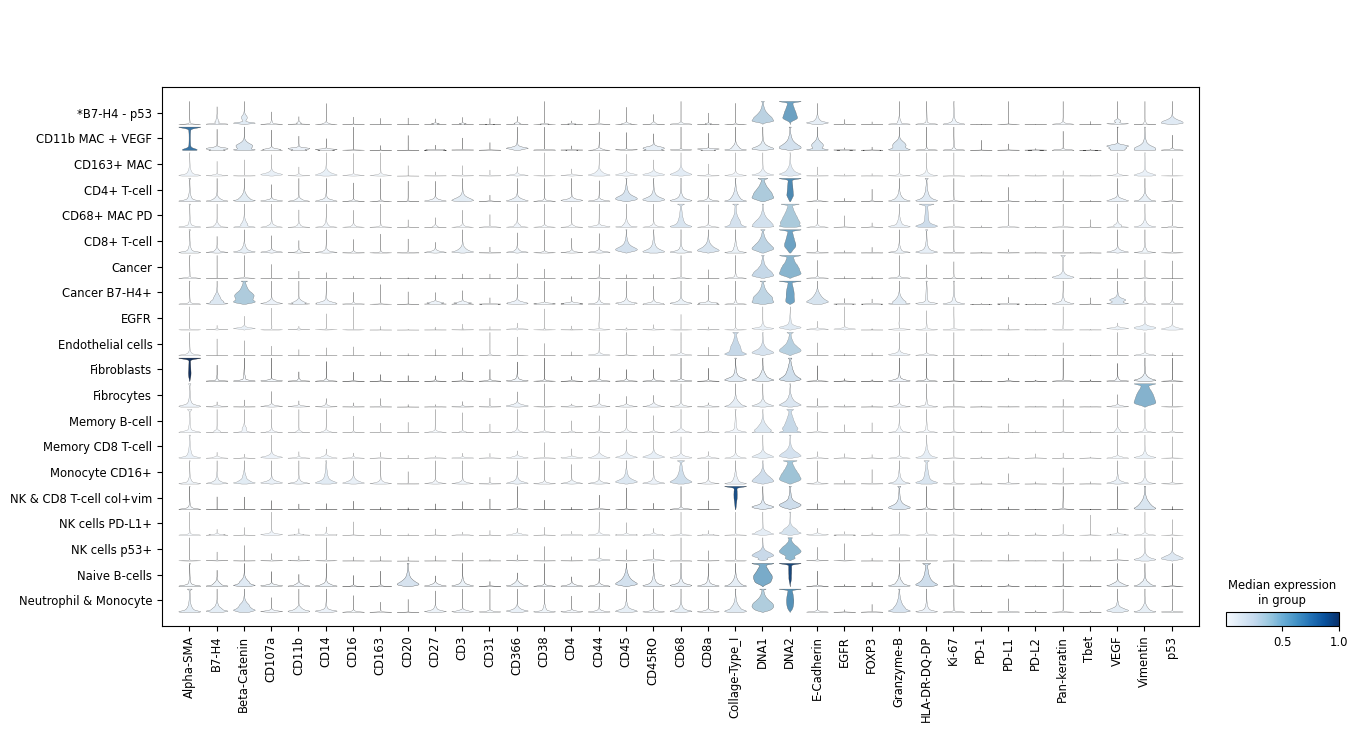

In [49]:
sc.pl.stacked_violin(adata,var_names = adata.var.index, groupby='Pixie',show = False);
#plt.savefig(output_fig+'/diff_expr_marker/cell_type__stacked_violing')

In [45]:

#plt.hist(adata.X.reshape(-1),20)

array([[0.02400859, 0.04439095, 0.01049406, ..., 0.07414779, 0.05084864,
        0.004914  ],
       [0.01186394, 0.0066368 , 0.00504318, ..., 0.02507198, 0.176109  ,
        0.01077913],
       [0.37299113, 0.0110851 , 0.        , ..., 0.03442449, 0.89249186,
        0.00948039],
       ...,
       [0.07973502, 0.02899032, 0.04455549, ..., 0.02253982, 0.00415655,
        0.02710249],
       [0.33423898, 0.05482289, 0.13214968, ..., 0.10554463, 0.05904529,
        0.03463117],
       [0.36802553, 0.04997452, 0.22203726, ..., 0.0800318 , 0.04819702,
        0.04604309]])

In [99]:
a = adata.obs[['acquisition_ID','SAMPLE_TYPE_(CORE/RESECTION)','Response']].value_counts()
b = {}
a = pd.DataFrame(a).reset_index()
b = a['SAMPLE_TYPE_(CORE/RESECTION)'].value_counts()
c = a[a['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].Response.value_counts()
c

Response
pCR              80
Non-Responder    53
Name: count, dtype: int64

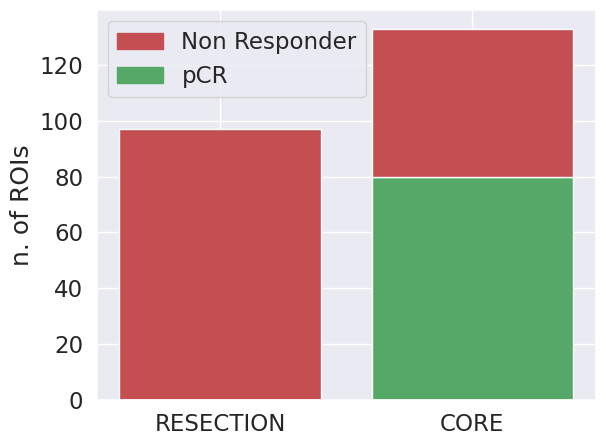

In [123]:
import matplotlib.patches as mpatches
sns.set(font_scale=1.5)
plt.bar(['RESECTION','CORE'],[b['RESECTION'],c['pCR']],color = ['C3','C2'])
plt.bar(['RESECTION','CORE'],[0,c['Non-Responder']],color = ['C0','C3'],bottom = [0,c['pCR']])
red_patch = mpatches.Patch(color='C3', label='Non Responder')
green_patch = mpatches.Patch(color='C2', label='pCR')
plt.legend(handles=[red_patch,green_patch])
plt.ylabel('n. of ROIs')
plt.tight_layout()
#plt.savefig('samples_ROI')


In [98]:
['RESECTION','CORE'],[b['RESECTION'],c['pCR']]
b['RESECTION']

SAMPLE_TYPE_(CORE/RESECTION)
CORE         133
RESECTION     97
Name: count, dtype: int64